loan approval - full pipeline project
---------------------------------------------
train accuracy: 0.946
test accuracy: 0.55
cv accuracy: 0.57
---------------------------------------------
              precision    recall  f1-score   support

    rejected       0.42      0.20      0.27        25
    approved       0.58      0.80      0.67        35

    accuracy                           0.55        60
   macro avg       0.50      0.50      0.47        60
weighted avg       0.51      0.55      0.51        60



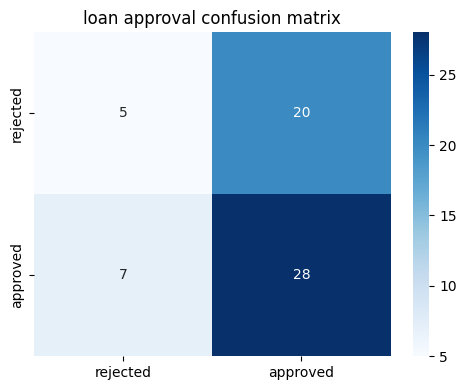

applicant: approved!
confidence: 65.7 %


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

data = {
    "age":        np.random.randint(21, 65, n),
    "income":     np.random.randint(15000, 200000, n),
    "loan_amount":np.random.randint(50000, 2000000, n),
    "credit":     np.random.randint(300, 900, n),
    "employment": np.random.choice(["salaried", "self employed", "business"], n),
    "city":       np.random.choice(["metro", "tier1", "tier2"], n),
    "approved":   np.random.choice([0, 1], n, p=[0.38, 0.62])
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n, 20), "income"] = np.nan
df.loc[np.random.choice(n, 15), "credit"] = np.nan

x = df.drop("approved", axis=1)
y = df["approved"]

num_cols = ["age", "income", "loan_amount", "credit"]
cat_cols = ["employment", "city"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

full_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=100,
                                          random_state=42))
])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

full_pipe.fit(x_train, y_train)
y_pred = full_pipe.predict(x_test)

print("loan approval - full pipeline project")
print("-" * 45)
print("train accuracy:", round(full_pipe.score(x_train, y_train), 3))
print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))

cv = cross_val_score(full_pipe, x, y, cv=5)
print("cv accuracy:", round(np.mean(cv), 3))
print("-" * 45)
print(classification_report(y_test, y_pred,
      target_names=["rejected", "approved"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["rejected", "approved"],
            yticklabels=["rejected", "approved"])
plt.title("loan approval confusion matrix")
plt.tight_layout()
plt.show()

new_applicant = pd.DataFrame([{
    "age": 32, "income": 65000,
    "loan_amount": 500000, "credit": 720,
    "employment": "salaried", "city": "metro"
}])

result = full_pipe.predict(new_applicant)
prob = full_pipe.predict_proba(new_applicant)
print("applicant:",
      "approved!" if result[0] == 1 else "rejected")
print("confidence:", round(max(prob[0]) * 100, 1), "%")